In [1]:
from scripts.utils import check_data, preprocess_data, save_data
from scripts.utils import PROJECT_PATH, DATA_PATH, RESULTS_PATH, CELLTYPE_MAP, HISTOTYPE_MAP, ANNDATA_MAP, SUBSETS_CONFIG

from scripts.gene_subsampling import neyman_subsample
from scripts.studies import study_sparsity, study_sparsity_with_trajectories, study_complete_sparsity, study_group_sparsity, study_group_sparsity_exclude
import numpy as np

from scripts.clustering import cluster_data, find_best_resolution, find_best_resolution_linspace, best_leiden_run

from scripts.utils import plot_UMAP, update_data
import os

%load_ext autoreload
%autoreload 2

c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
celltype="Endothelial cells"

endothelial_cells = check_data(celltype=celltype,data_path=DATA_PATH)
if endothelial_cells is None:
    endothelial_cells = preprocess_data(celltype=celltype, with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=endothelial_cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP[celltype]}")

In [3]:
n_cells=1e3
endothelial_cells =neyman_subsample(data=endothelial_cells,target_labels=["Endothelial cells"],label_col="celltype_label",stratify_by=["cellstates_tme"],n_target=n_cells)
endothelial_cells = update_data(data=endothelial_cells)

c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\utils.py:251: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  data.X = residuals
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


In [4]:
endothelial_cells

AnnData object with n_obs × n_vars = 1000 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

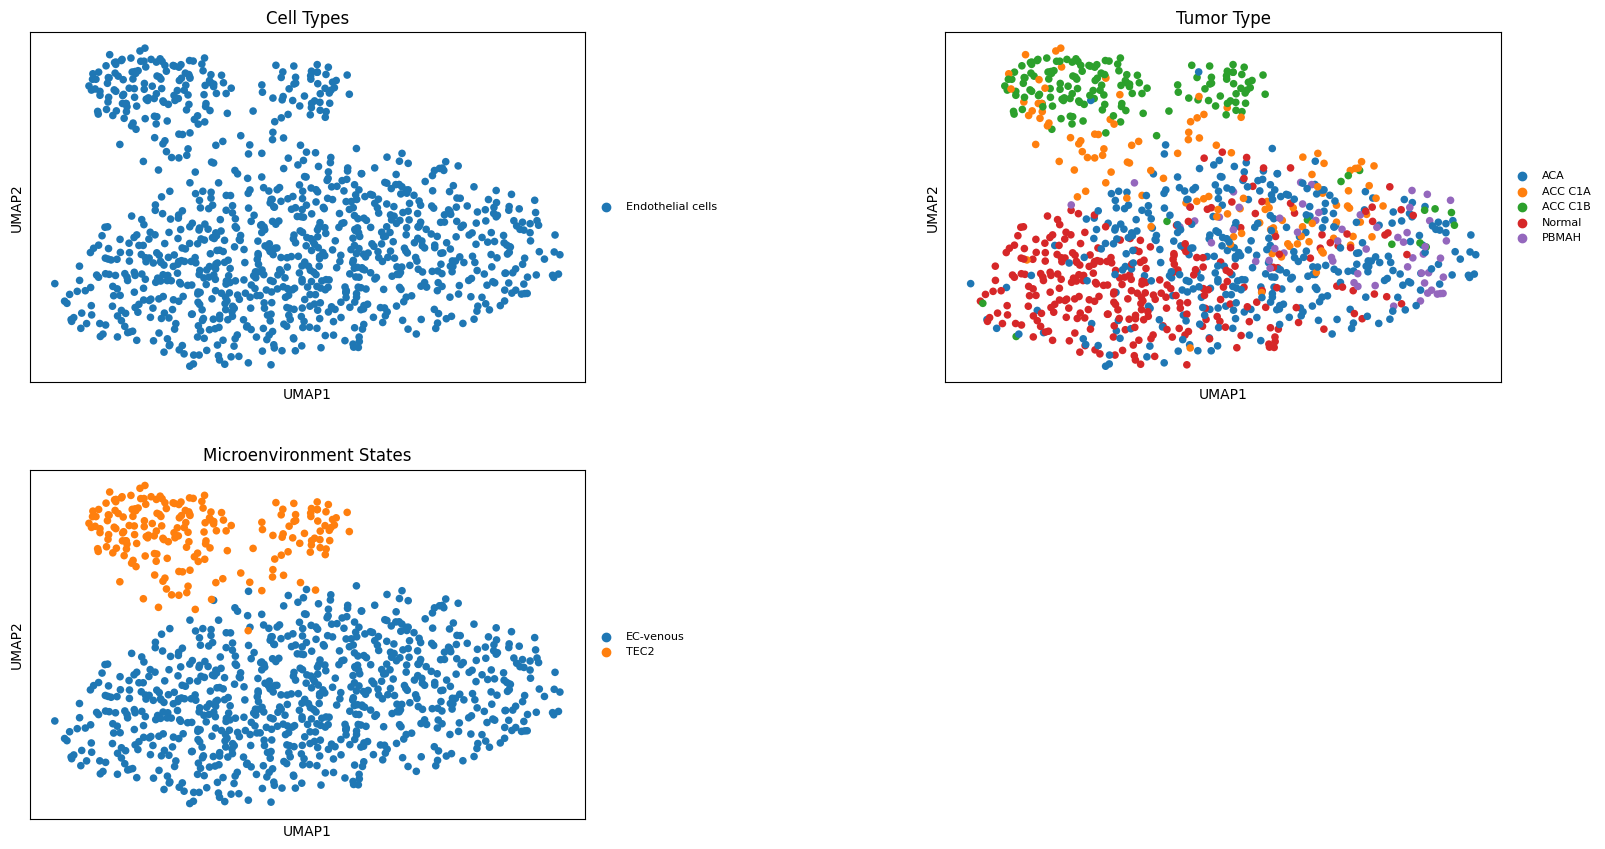

In [4]:
plot_UMAP(endothelial_cells)

Ratio=0.010


c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\clustering.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(data,resolution=resolution,key_added='leiden_temp', random_state=random_state)




Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


Ratio=0.143


Ratio=0.170


Ratio=0.197


Ratio=0.223


Ratio=0.250


Ratio=0.010


Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


Ratio=0.143


Ratio=0.170


Ratio=0.197


Ratio=0.223


Ratio=0.250


Ratio=0.010


Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


Ratio=0.143


Ratio=0.170


Ratio=0.197


Ratio=0.223


Ratio=0.250


Ratio=0.010


Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


Ratio=0.143


Ratio=0.170


Ratio=0.197


Ratio=0.223


Ratio=0.250


Ratio=0.010


Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


Ratio=0.143


Ratio=0.170


Ratio=0.197


Ratio=0.223


Ratio=0.250




AttributeError: 'Axes' object has no attribute 'show'

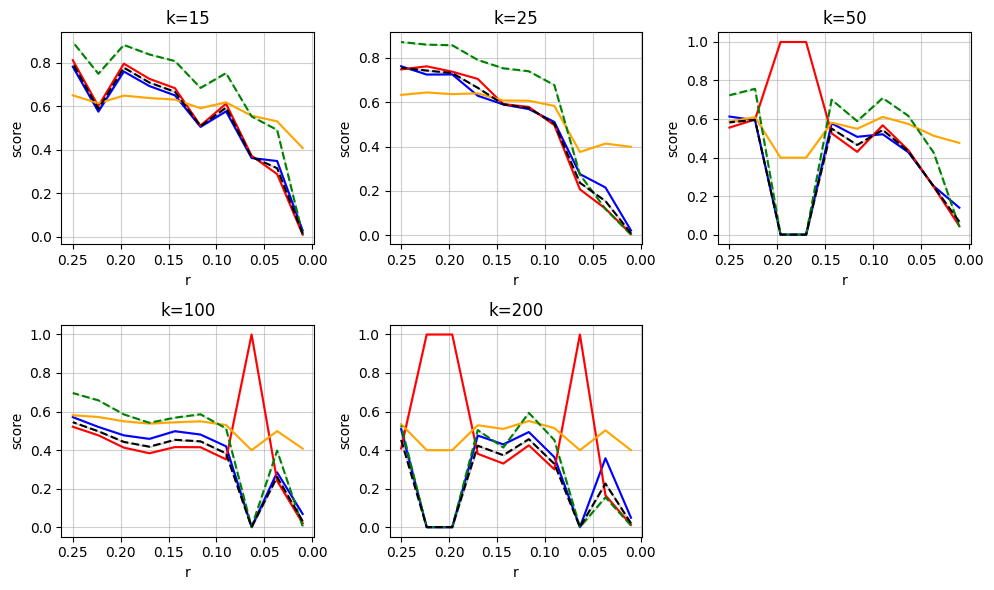

In [5]:
n_points_ratio = 10
n_runs = 1
n_neighbors_candidates = [15,25,50,100,200]

ratio_candidates = np.linspace(0.01,0.25,n_points_ratio)
labels = endothelial_cells.obs["cellstates_tme"]
show = True

sparsity_results = study_complete_sparsity(endothelial_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors_candidates=n_neighbors_candidates, show=show)

In [ ]:
n_points_ratio = 10
n_runs = 25
n_neighbors_candidates = [15,25,50,100,200]

ratio_candidates = np.linspace(0.01,1,n_points_ratio)
labels = endothelial_cells.obs["cellstates_tme"]
show = True

sparsity_results = study_complete_sparsity(endothelial_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors_candidates=n_neighbors_candidates, show=show)

In [ ]:
n_points_ratio = 10
n_runs = 25
ratio_candidates = np.linspace(0.01,1,n_points_ratio)
n_neighbors=20
study_group_sparsity(endothelial_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)

In [ ]:
n_points_ratio = 10
n_runs = 25
ratio_candidates = np.linspace(0.01,1,n_points_ratio)
n_neighbors=20
study_group_sparsity_exclude(endothelial_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)

In [ ]:
n_points_ratio = 10
n_runs = 25
ratio_candidates = np.linspace(0.01,0.25,n_points_ratio)
n_neighbors=20
study_group_sparsity_exclude(endothelial_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)